<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>HIERARCHICAL CLUSTER  </h2>
</div>

- Clustering is unsupervised Learning
- Clustering means grouping of objects based on the information found in the data, describing the objects or their relationship.
- Clustering is automatic classification. Here data will be unstructured or unlabelled data.
- Elbow curve, Distoration(Within cluster sum of square -WCSS) vs no of cluster to identify final no of cluster in model, some time Dendogram used to find K.
- In Agglomaritive, no centroid concept and in that fit_predict is there but just predict is not there 
- The clustering technique can be very handy when it comes to unlabeled data. Since most of the data in the real-world is unlabeled and annotating the data has higher costs, clustering techniques can be used to label unlabeled data.


##### Types Of Clustering			
    > 1.Exclusive Clustering(K-Mean Clustering)		
            - Here data item/points belongs to one cluster exclusively.	
    > 2. Overlapping Clustering(Fuzzy C-Mean cluster)	
            - Here data item/points belongs to more than one cluster.	
    > 3.Hierarchical Clustering(1. Agglomerative Clustering:2. Division Clustering:)
            - When 2 cluster will have parent-child relationship, or tree like structure, then its called Hierarchial cluster.	Dendogram or Tree like structure will be build



- affinity : Metric used to compute the linkage. Can be {“euclidean”, “l1”, “l2”, “manhattan”, “cosine”, or ‘precomputed’.} If linkage is “ward”, only “euclidean” is accepted.

- linkage : {“ward”, “complete”, “average”, “single”}, , optional (default=”ward”)
Which linkage criterion to use.

- ward minimizes the variance of the clusters being merged.

- average uses the average of the distances of each feature of the two sets.

- complete or maximum linkage uses the maximum distances between all features of the two sets.

- single uses the minimum of the distances between all observations of the two sets.

<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

> Eventually after collecting this data set the company hired you as a machine earning scientist to segment their clients in 
different groups based on these two metrics, 'the annual income' and 'the spending score' and since the mall has no idea of what 
this client segments might be or even has no idea about how many segments there would be.

##  1. Import all Librariy

In [1]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

In [2]:
customer_data = pd.read_csv(r"..\Dataset\shopping_data.csv")  
customer_data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Data Exploration

In [3]:
customer_data.shape  

(200, 5)

- To view the results in two-dimensional feature space, we will retain only two of these five columns. We can remove CustomerID column, Genre, and Age column. We will retain the Annual Income (in thousands of dollars) and Spending Score (1-100) columns.  

In [4]:
data = customer_data.iloc[:, 3:5].values  
data

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

### 2.1 Dendogram with Linkage = 'ward'

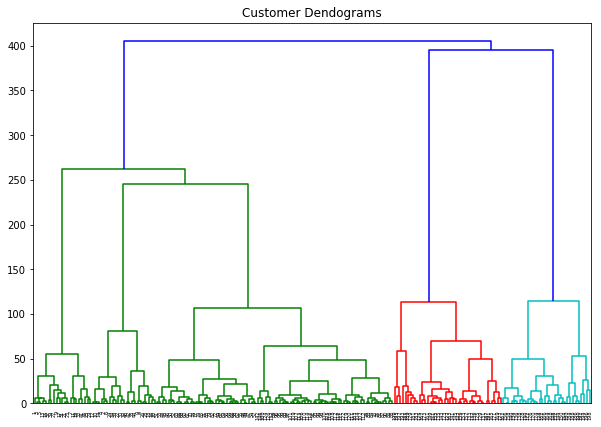

In [5]:
Z =  linkage(data, method='ward')
plt.figure(figsize=(10, 7))  
plt.title("Customer Dendograms")  
dend = dendrogram(Z)  

### 2.2.1 CONCLUSION:

- If we draw a horizontal line that passes through longest distance without a horizontal line, we get 5 clusters 

### 2.2 Dendogram with Linkage = 'single'

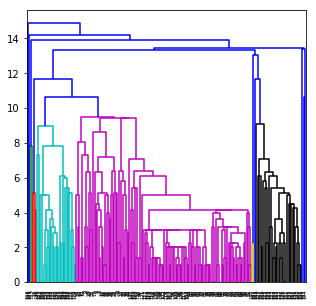

In [6]:
#Plot the dendogram as single
# 2. using linkage 'single'
Z = linkage(data, 'single')
fig = plt.figure(figsize = (5,5))
dn = dendrogram(Z)
# It looks complex
plt.show()

## 3. Building Machine Learning - Agglomerative Cluster( Bottom Up algorithm)



- Now we know the number of clusters for our dataset, the next step is to group the data points into these five clusters. To do so we will again use the AgglomerativeClustering class of the sklearn.cluster library. Take a look at the following script:

In [7]:
from sklearn.cluster import AgglomerativeClustering

"""
In the code above we import the AgglomerativeClustering class from the "sklearn.cluster" library. 
The number of parameters is set to 2 using the n_clusters parameter 
while the affinity is set to "euclidean" (distance between the datapoints). 
Finally linkage parameter is set to "ward", which minimizes the variant between the clusters.
"""

cluster = AgglomerativeClustering(n_clusters=5, affinity='euclidean', linkage='ward')  
cluster.fit_predict(data)  


#This is the label of the datapoint, which are cluster id's

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2], dtype=int64)

- Next we call the fit_predict method from the AgglomerativeClustering class variable cluster labels_. This method returns the names of the clusters that each data point belongs to

In [8]:
print(cluster.labels_)  

"""
The output is a one-dimensional array of 10 elements corresponding to the clusters assigned to our 10 data points.
"""

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 1 2
 0 2 0 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


'\nThe output is a one-dimensional array of 10 elements corresponding to the clusters assigned to our 10 data points.\n'

## 4. Model Evaluation with Visualization

Text(0, 0.5, 'Spending Score (1-100)')

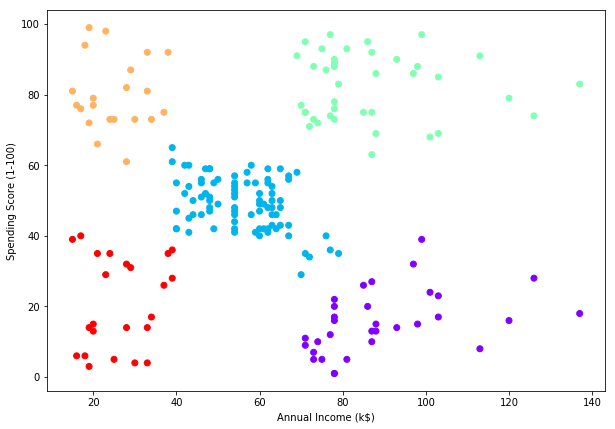

In [9]:
##PLOT THIS - method 1
plt.figure(figsize=(10, 7))  
plt.scatter(data[:,0], data[:,1], c=cluster.labels_, cmap='rainbow')  
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

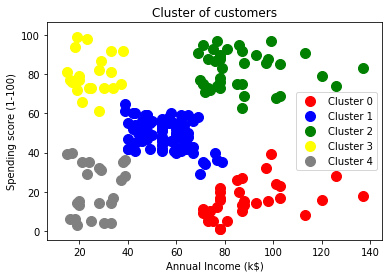

In [11]:
##PLOT THIS - method 2
"""
Explaining visualization code
In general: plt.scatter(X_axis_data, Y_axis_data, ....)
In our code: X contains input data (X_axis_data, Y_axis_data) and y_means contains output 
    i.e cluster ids(0 to 4)
X[y_kmeans == 0, 0] -> first '0' means the cluster id 0, second 0 is first column of X,
    it would return X co-ordinates for cluster 0
X[y_kmeans == 0, 1] -> '0' means the cluster id 0, 1 is second column of X that is y-axis 
    for scatter method

s = 100 is the size

"""

# In Agglomaritive, no centroid concept
plt.scatter(data[cluster.labels_ == 0, 0], data[cluster.labels_ == 0, 1],
           s=100, c='red', label='Cluster 0')
plt.scatter(data[cluster.labels_ == 1, 0],data[cluster.labels_ == 1, 1],
           s=100, c='blue', label='Cluster 1')
plt.scatter(data[cluster.labels_ == 2, 0], data[cluster.labels_ == 2, 1],
           s=100, c='green', label='Cluster 2')
plt.scatter(data[cluster.labels_ == 3, 0], data[cluster.labels_ == 3, 1],
           s=100, c='yellow', label='Cluster 3')
plt.scatter(data[cluster.labels_ == 4, 0], data[cluster.labels_ == 4, 1],
           s=100, c='gray', label='Cluster 4')

plt.title("Cluster of customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending score (1-100)")
plt.legend()
plt.show()

## 5. CONCLUSION:
You can see the data points in the form of five clusters. 
   -  Cluster 0 : The data points in the bottom right(Red) belong to the customers with high salaries but low spending. 
           - These are the customers that spend their money carefully. 
   -  Cluster 2 : Similarly, the customers at top right (Green data points), these are the customers with high salaries and high spending.
            These are the type of customers that companies target. 
   - Cluster 1 : The customers in the middle (blue data points) are the ones with average income and average salaries. 
           - The highest numbers of customers belong to this category. 
           - Companies can also target these customers given the fact that 
        they are in huge numbers, etc.
   -  Cluster 3 , 4 : Similarly, the customers at top left nand below left (Gray and yellow data points), these are the customers with Low salaries and high and low spending. No need to target them

### 5.1 Conclusion
The clustering technique can be very handy when it comes to unlabeled data. Since most of the data in the real-world is unlabeled and annotating the data has higher costs, clustering techniques can be used to label unlabeled data.

## 6. Append Cluuster no to origina Data

In [12]:
"""
- cluster 0: careful
- cluster 1: standard
- cluster 2: sensible 
- cluster 3: careless
- cluster 4: No target

"""
# Append o/p to original dataset
customer_data['cluster_Hierarchy'] = cluster.labels_
customer_data['cluster_Hierarchy'] = customer_data['cluster_Hierarchy'].map({0:'careful',1:'standard',2:'sensible',3:'careless', 4:'No Target'})

In [14]:
print(" Customer id which have High salary High spending: \n" , customer_data[customer_data["cluster_Hierarchy"] == 'sensible'].CustomerID)

print("\n" +" ###"*10)

print("\n Customer id which have High salary Low spending: \n" , customer_data[customer_data["cluster_Hierarchy"] == 'careful'].CustomerID)


 Customer id which have High salary High spending: 
 123    124
125    126
127    128
129    130
131    132
133    134
135    136
137    138
139    140
141    142
143    144
145    146
147    148
149    150
151    152
153    154
155    156
157    158
159    160
161    162
163    164
165    166
167    168
169    170
171    172
173    174
175    176
177    178
179    180
181    182
183    184
185    186
187    188
189    190
191    192
193    194
195    196
197    198
199    200
Name: CustomerID, dtype: int64

 ### ### ### ### ### ### ### ### ### ###

 Customer id which have High salary Low spending: 
 128    129
130    131
134    135
136    137
138    139
140    141
144    145
148    149
150    151
152    153
154    155
156    157
158    159
162    163
164    165
166    167
168    169
170    171
172    173
174    175
176    177
178    179
180    181
182    183
184    185
186    187
188    189
190    191
192    193
194    195
196    197
198    199
Name: CustomerID, dtype: int64
